Imports

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import os
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from os import listdir

Reading data

In [3]:
folder_dir = "/home/davide/Documents/Deepfake-Classification/deepfake-classification"
img_dir = "/home/davide/Documents/Deepfake-Classification/deepfake-classification/train"

test_dir = "/home/davide/Documents/Deepfake-Classification/deepfake-classification/test"
test_file = os.path.join(folder_dir, "test.csv")  

csv_file = os.path.join(folder_dir, "train.csv")

validation_file = os.path.join(folder_dir, "validation.csv")
val_dir = "/home/davide/Documents/Deepfake-Classification/deepfake-classification/validation"

Training

Device: cuda
=== Epoch 1 ===
Batch 0, Loss: 2.3603
Batch 100, Loss: 0.9855
Batch 200, Loss: 0.7775
Batch 300, Loss: 0.5589
Epoch 1 Loss: 0.8472, Accuracy: 0.6696
=== Epoch 2 ===
Batch 0, Loss: 0.5918
Batch 100, Loss: 0.6187
Batch 200, Loss: 0.4631
Batch 300, Loss: 0.3466
Epoch 2 Loss: 0.6070, Accuracy: 0.7674
=== Epoch 3 ===
Batch 0, Loss: 0.5485
Batch 100, Loss: 0.5719
Batch 200, Loss: 0.4137
Batch 300, Loss: 0.3440
Epoch 3 Loss: 0.5231, Accuracy: 0.7976
=== Epoch 4 ===
Batch 0, Loss: 0.5336
Batch 100, Loss: 0.4249
Batch 200, Loss: 0.4378
Batch 300, Loss: 0.4495
Epoch 4 Loss: 0.4855, Accuracy: 0.8142
=== Epoch 5 ===
Batch 0, Loss: 0.3622
Batch 100, Loss: 0.3393
Batch 200, Loss: 0.3298
Batch 300, Loss: 0.4460
Epoch 5 Loss: 0.4541, Accuracy: 0.8286
=== Epoch 6 ===
Batch 0, Loss: 0.3481
Batch 100, Loss: 0.4364
Batch 200, Loss: 0.4680
Batch 300, Loss: 0.4364
Epoch 6 Loss: 0.4250, Accuracy: 0.8399
=== Epoch 7 ===
Batch 0, Loss: 0.3659
Batch 100, Loss: 0.3847
Batch 200, Loss: 0.5119
Batch 3

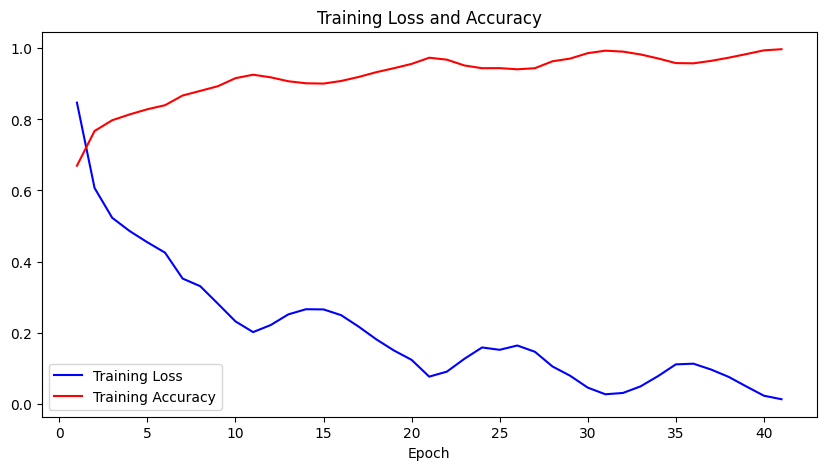

In [6]:
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1_1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1, bias=False)
        self.bn1_1 = nn.BatchNorm2d(32)
        self.conv1_2 = nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False)
        self.bn1_2 = nn.BatchNorm2d(32)

        self.conv2_1 = nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False)
        self.bn2_1 = nn.BatchNorm2d(64)
        self.conv2_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False)
        self.bn2_2 = nn.BatchNorm2d(64)

        self.conv3_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False)
        self.bn3_1 = nn.BatchNorm2d(128)
        self.conv3_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False)
        self.bn3_2 = nn.BatchNorm2d(128)
        self.conv3_3 = nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False)
        self.bn3_3 = nn.BatchNorm2d(128)

        self.conv4_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False)
        self.bn4_1 = nn.BatchNorm2d(256)
        self.conv4_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False)
        self.bn4_2 = nn.BatchNorm2d(256)
        self.conv4_3 = nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False)
        self.bn4_3 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, 10)

    def forward(self, x):
        
        x = F.relu(self.bn1_1(self.conv1_1(x)))
        x = F.relu(self.bn1_2(self.conv1_2(x)))
        x = self.pool(x)

        x = F.relu(self.bn2_1(self.conv2_1(x)))
        x = F.relu(self.bn2_2(self.conv2_2(x)))
        x = self.pool(x)

        x = F.relu(self.bn3_1(self.conv3_1(x)))
        x = F.relu(self.bn3_2(self.conv3_2(x)))
        x = F.relu(self.bn3_3(self.conv3_3(x)))
        x = self.pool(x)

        x = F.relu(self.bn4_1(self.conv4_1(x)))
        x = F.relu(self.bn4_2(self.conv4_2(x)))
        x = F.relu(self.bn4_3(self.conv4_3(x)))
        x = self.pool(x)

        x = self.global_avg_pool(x) 
        x = torch.flatten(x, 1)      
        x = self.dropout(x)
        x = self.fc(x)
        return x

    
model = NeuralNet()

df_train = pd.read_csv(csv_file)

data = []
for idx, row in df_train.iterrows():
    img_name = row['image_id'] + '.png'
    label = row['label']
    img_path = os.path.join(img_dir, img_name)
    image = cv2.imread(img_path)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # height, width, channels = image_rgb.shape

    # print(f"Original image width: {width} pixels")   100
    # print(f"Original image height: {height} pixels") 100
    # print(f"Number of channels: {channels}")         3
    image_resized = cv2.resize(image_rgb, (100, 100))
    normalized_image = cv2.normalize(image_resized.astype('float32'), None, 0, 1, cv2.NORM_MINMAX)

    image_tensor = torch.from_numpy(normalized_image).permute(2, 0, 1).float()

    data.append((image_tensor, label))

images = torch.stack([item[0] for item in data])
labels = torch.tensor([item[1] for item in data])

dataset = TensorDataset(images, labels)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=8)

# optimizer = torch.optim.Adam(model.parameters(), lr=0.006, weight_decay=1e-5)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.82, weight_decay=1e-4, nesterov=True)
scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.001, max_lr=0.01, step_size_up=2000)


NUM_EPOCHS = 130
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
model = model.to(device) 
loss_function = nn.CrossEntropyLoss() 

train_losses = []
train_accuracies = []

model.train(True)
for epoch in range(NUM_EPOCHS): 
    print(f"=== Epoch {epoch+1} ===")
    ####################
    running_loss = 0.0
    correct = 0
    total = 0
    ###################
    for i, (inputs, labels) in enumerate(train_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

#####################################################
        running_loss += loss.item() * inputs.size(0)
        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
#####################################################

        if i % 100 == 0:
            print(f"Batch {i}, Loss: {loss.item():.4f}")

##################################################################################
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    # scheduler.step(epoch_loss)
    print(f"Epoch {epoch+1} Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")
    if epoch_acc > 0.995:
        print(f"Stopping early at epoch {epoch+1} as accuracy is {epoch_acc: .4f}")
        break
##################################################################################
print('Finished Training')
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, 'b-', label='Training Loss')
plt.plot(epochs, train_accuracies, 'r-', label='Training Accuracy')
plt.xlabel('Epoch')
plt.title('Training Loss and Accuracy')
plt.legend()
plt.show()


Test

In [10]:
df_test = pd.read_csv(test_file)

test_data = []
image_ids = []
for idx, row in df_test.iterrows():
    img_name = row['image_id'] + '.png'
    img_path = os.path.join(test_dir, img_name)
    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image_rgb, (100, 100))
    
    normalized_image = cv2.normalize(image_resized.astype('float32'), None, 0, 1, cv2.NORM_MINMAX)
    image_tensor = torch.from_numpy(normalized_image).permute(2, 0, 1).float()
    test_data.append(image_tensor)
    image_ids.append(row['image_id'])

test_images = torch.stack(test_data)
test_dataset = TensorDataset(test_images) 
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=8)

model.to(device)
model.eval()
predicted_labels = []
with torch.no_grad():
    for image_batch in test_loader:
        images = image_batch[0].to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()
        predicted_labels.extend(preds.tolist())

print(predicted_labels)
predictions_df = pd.DataFrame({'image_id': image_ids, 'label': predicted_labels})
predictions_df.to_csv('deepfake-classification/prediction.csv', index=False)
print("Predictions saved to prediction.csv")


[4, 3, 0, 2, 1, 3, 0, 4, 3, 1, 3, 2, 3, 2, 2, 1, 0, 3, 3, 3, 4, 0, 0, 0, 1, 3, 4, 2, 4, 3, 3, 4, 0, 1, 2, 0, 4, 1, 3, 1, 0, 0, 0, 2, 0, 2, 1, 2, 4, 3, 4, 1, 3, 1, 3, 3, 2, 1, 2, 4, 1, 2, 2, 0, 4, 2, 1, 4, 2, 1, 3, 1, 0, 0, 1, 2, 3, 2, 2, 3, 1, 1, 2, 0, 3, 1, 4, 0, 2, 0, 0, 1, 3, 1, 1, 4, 0, 3, 2, 4, 3, 3, 3, 2, 4, 2, 3, 4, 2, 4, 4, 0, 3, 1, 2, 2, 1, 3, 4, 1, 3, 1, 4, 1, 0, 2, 3, 4, 2, 4, 4, 3, 1, 3, 4, 2, 0, 1, 1, 2, 3, 1, 4, 3, 3, 2, 3, 3, 0, 3, 2, 0, 1, 2, 2, 1, 3, 1, 0, 4, 0, 0, 2, 4, 0, 2, 2, 4, 2, 1, 3, 1, 4, 4, 0, 4, 4, 4, 1, 0, 1, 3, 2, 1, 2, 4, 2, 3, 3, 2, 2, 2, 3, 1, 4, 3, 2, 0, 0, 0, 2, 4, 2, 2, 1, 0, 3, 0, 3, 1, 0, 0, 0, 0, 2, 4, 4, 1, 1, 4, 0, 1, 3, 1, 0, 2, 4, 4, 1, 0, 2, 4, 3, 4, 4, 0, 3, 2, 2, 1, 0, 2, 0, 1, 0, 3, 1, 0, 3, 1, 4, 3, 3, 1, 3, 1, 3, 0, 2, 2, 1, 2, 4, 1, 4, 1, 4, 0, 4, 0, 4, 4, 1, 0, 4, 0, 3, 4, 2, 2, 4, 4, 3, 0, 0, 0, 3, 1, 4, 2, 0, 4, 1, 2, 3, 1, 1, 4, 3, 3, 3, 3, 1, 4, 0, 3, 4, 0, 4, 4, 3, 1, 3, 1, 3, 3, 0, 4, 1, 2, 4, 4, 0, 4, 0, 4, 2, 0, 0, 2, 0, 0, 1, 

Validation

In [ ]:
df_val = pd.read_csv(validation_file)

val_data = []
for idx, row in df_val.iterrows():
    img_name = row['image_id'] + '.png'
    label = row['label']
    img_path = os.path.join(val_dir, img_name)
    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image_rgb, (100, 100))
    
    normalized_image = cv2.normalize(image_resized.astype('float32'), None, 0, 1, cv2.NORM_MINMAX)
    image_tensor = torch.from_numpy(normalized_image).permute(2, 0, 1).float()
    val_data.append((image_tensor, label))

val_images = torch.stack([item[0] for item in val_data])
val_labels = torch.tensor([item[1] for item in val_data])

val_dataset = TensorDataset(val_images, val_labels)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=8)

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f'Validation Accuracy: {accuracy*100:.2f}%')

# 92.88%

Validation Accuracy: 92.88%
